In [1]:
from SCFT_DNA.SCFT_functions import *
from SCFT_DNA.DNA_input import *

import numpy as np
import matplotlib.pyplot as plt

Using cupy


Setting up the chain sequence

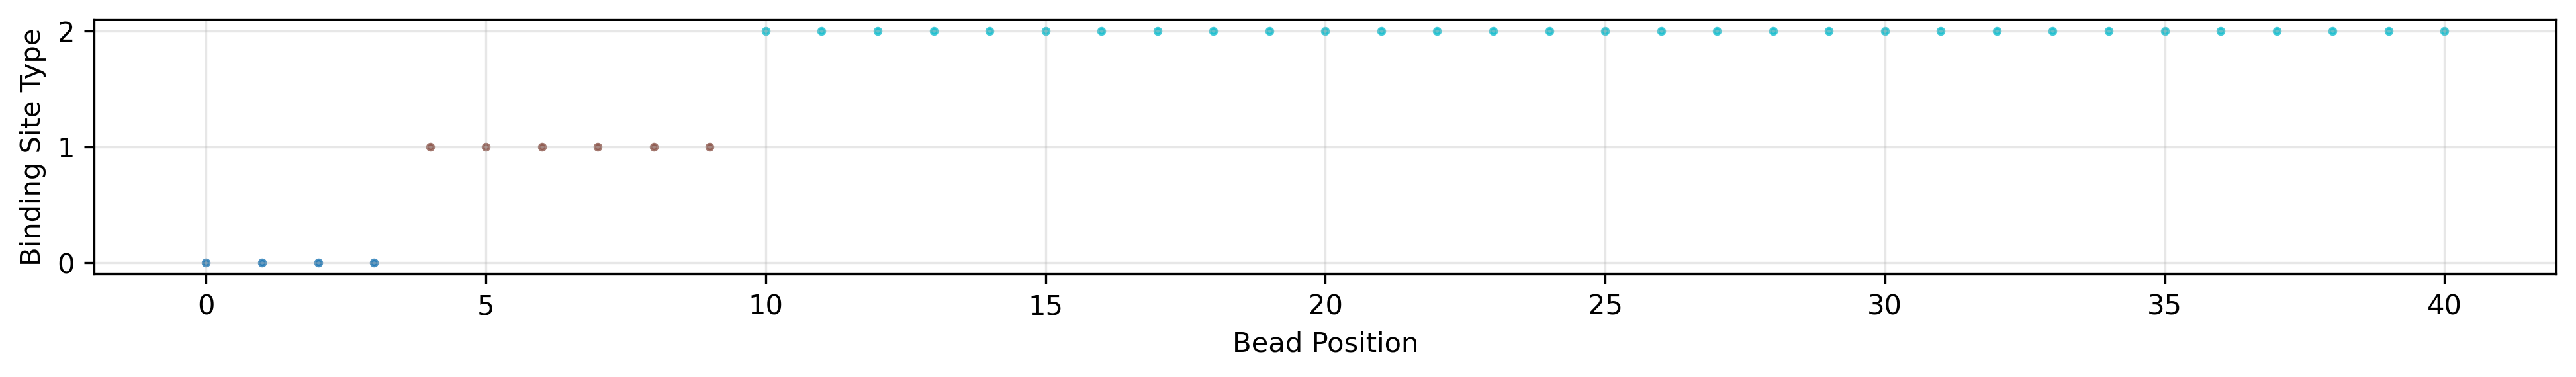

In [2]:
ns = 40

fa = 0.1
fb = 0.15
fc = 0.75

chain_interaction = np.zeros((3, ns+1))
chain_interaction[0, 0:int((ns+1)*fa)] += 1 # type A
chain_interaction[1, int((ns+1)*fa):int((ns+1)*fa+(ns+1)*fb)] += 1 # type B
chain_interaction[2, int((ns+1)*fa+(ns+1)*fb):] += 1 #type C

bead_sequence = onehot_to_color_labels(chain_interaction)
visualize_config(bead_sequence, chain_interaction.shape[0])

Same result as the paper, but the polymer contour is not normalized, and the interaction energy is per kuhn length (instead of Chi_N)

In [3]:
N = 1
Nseg = 20

chi_bs = 30
chi_cs = 30
chi_polymer_s = np.array([0.5, chi_bs, chi_cs]) /Nseg

chi_N_polymer = 15
chi_matrix = chi_N_polymer * np.ones((chain_interaction.shape[0], chain_interaction.shape[0])) / Nseg
np.fill_diagonal(chi_matrix, 0)

nx = ny = 128
initial_qsr = np.ones((nx, ny))
L = 100 #dimension of the box

polymer = Scft(
    N = N,
    Lx=L, Ly=L,
    phibar=0.1, # volume fraction of polymer
    l_p=np.sqrt(N),
    n_seg=Nseg, # contour length of polymer normalized from 0-1
    nx=nx, ny=ny,
    ns=ns,
    iterations=500,
    error_tol=1e-12,
    chain_interaction=chain_interaction,
    self_avoiding=0,
    initial_qsr=initial_qsr / np.mean(initial_qsr),
    mixing_rate=0.05,
    chi_polymer_block = chi_matrix ,
    chi_polymer_s = chi_polymer_s,
    PB = 2,
    close_boundary=False,
)

Same parameter set as the reference paper, where the polymer contour is normalized from 0 to 1

In [4]:
N = 20
Nseg = 1

chi_divider = 20 * np.sqrt(1)

chi_bs = 30
chi_cs = 30
chi_polymer_s = np.array([0.5, chi_bs, chi_cs])

chi_N_polymer = 15
chi_matrix = chi_N_polymer * np.ones((chain_interaction.shape[0], chain_interaction.shape[0]))
np.fill_diagonal(chi_matrix, 0)

nx = ny = 128
initial_qsr = np.ones((nx, ny))
L = 100  #dimension of the box

polymer = Scft(
    N = N,
    Lx=L, Ly=L,
    phibar=0.1, # volume fraction of polymer
    l_p=np.sqrt(N),
    n_seg=Nseg, # contour length of polymer normalized from 0-1
    nx=nx, ny=ny,
    ns=ns,
    iterations=500,
    error_tol=1e-12,
    chain_interaction=chain_interaction,
    self_avoiding=0,
    initial_qsr=initial_qsr / np.mean(initial_qsr),
    mixing_rate=0.05,
    chi_polymer_block = chi_matrix ,
    chi_polymer_s = chi_polymer_s,
    PB = 1,
    close_boundary=False,
)

Parameter sets to zoom length of the polymer and the box

In [7]:
multiplier = 2
N = 20 * multiplier
Nseg = 1

chi_bs = 30
chi_cs = 30
chi_polymer_s = np.array([0.5, chi_bs, chi_cs]) * np.sqrt(multiplier)

chi_N_polymer = 15
chi_matrix = chi_N_polymer * np.ones((chain_interaction.shape[0], chain_interaction.shape[0])) * np.sqrt(multiplier)
np.fill_diagonal(chi_matrix, 0)

nx = ny = 128
initial_qsr = np.ones((nx, ny))
L = 100 * np.sqrt(multiplier) #dimension of the box

polymer = Scft(
    N = N,
    Lx=L, Ly=L,
    phibar=0.1, # volume fraction of polymer
    l_p=np.sqrt(N),
    n_seg=Nseg, # contour length of polymer normalized from 0-1
    nx=nx, ny=ny,
    ns=ns,
    iterations=2000,
    error_tol=1e-12,
    chain_interaction=chain_interaction,
    self_avoiding=0,
    initial_qsr=initial_qsr / np.mean(initial_qsr),
    mixing_rate=0.05,
    chi_polymer_block = chi_matrix ,
    chi_polymer_s = chi_polymer_s,
    PB = 2,
    close_boundary=False,
)

In [5]:
wsr, qsr_initial, qsr_d_initial, diff, free_energy_hist = initialization(polymer, seed = 5, shift = 0)

In [6]:
mixing_rate=0.05
polymer.iterations = 300
wsr, phi, phi_blocks, qsr, qsr_d, diff, free_energy_hist = scft_loop(polymer, wsr, qsr_initial, qsr_d_initial, diff, free_energy_hist)

100%|██████████| 300/300 [00:12<00:00, 23.57it/s]


(0.0, 18666.908203125)

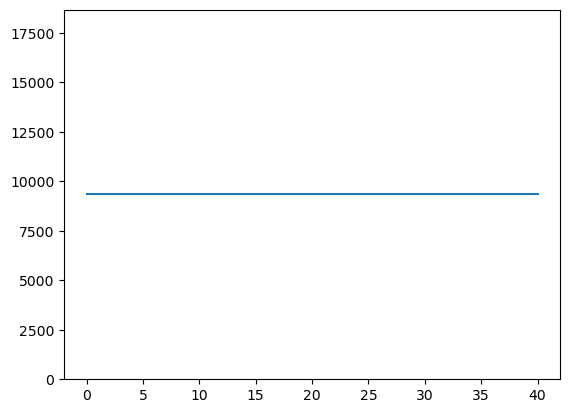

In [16]:
sum_rho = np.sum(to_numpy(qsr*qsr_d), axis = (1,2))
plt.plot(sum_rho)
plt.ylim((0,2*np.max(sum_rho)))

0.04623286703044582


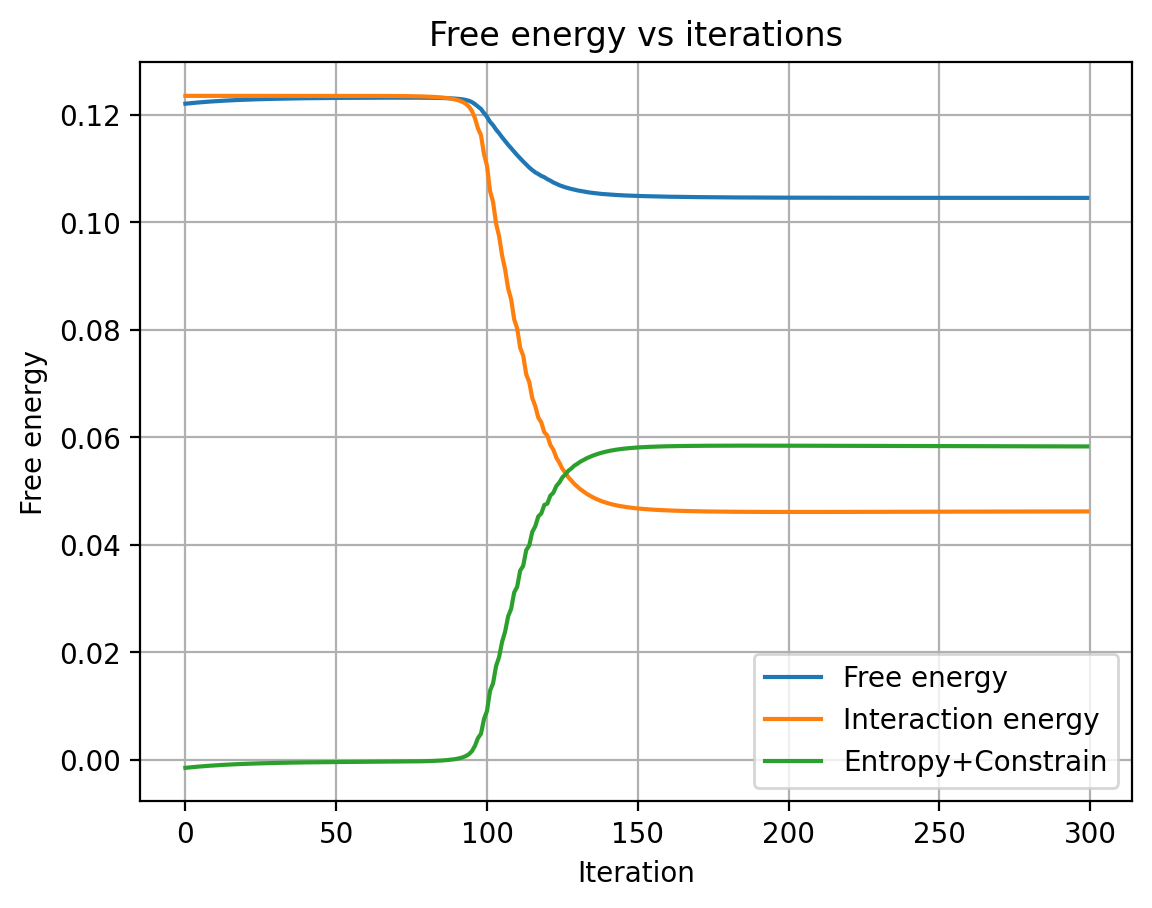

In [7]:
plt.figure(dpi=200)
free_energy_hist = np.array(free_energy_hist)
plt.plot(free_energy_hist[:, 0],label="Free energy")
plt.plot(free_energy_hist[:, 1],label="Interaction energy")
plt.plot(free_energy_hist[:, 2],label="Entropy+Constrain")
#plt.yscale('log')
plt.title("Free energy vs iterations")
plt.ylabel("Free energy")
plt.xlabel("Iteration")
plt.legend()
plt.grid()
print(free_energy_hist[-1, 1])

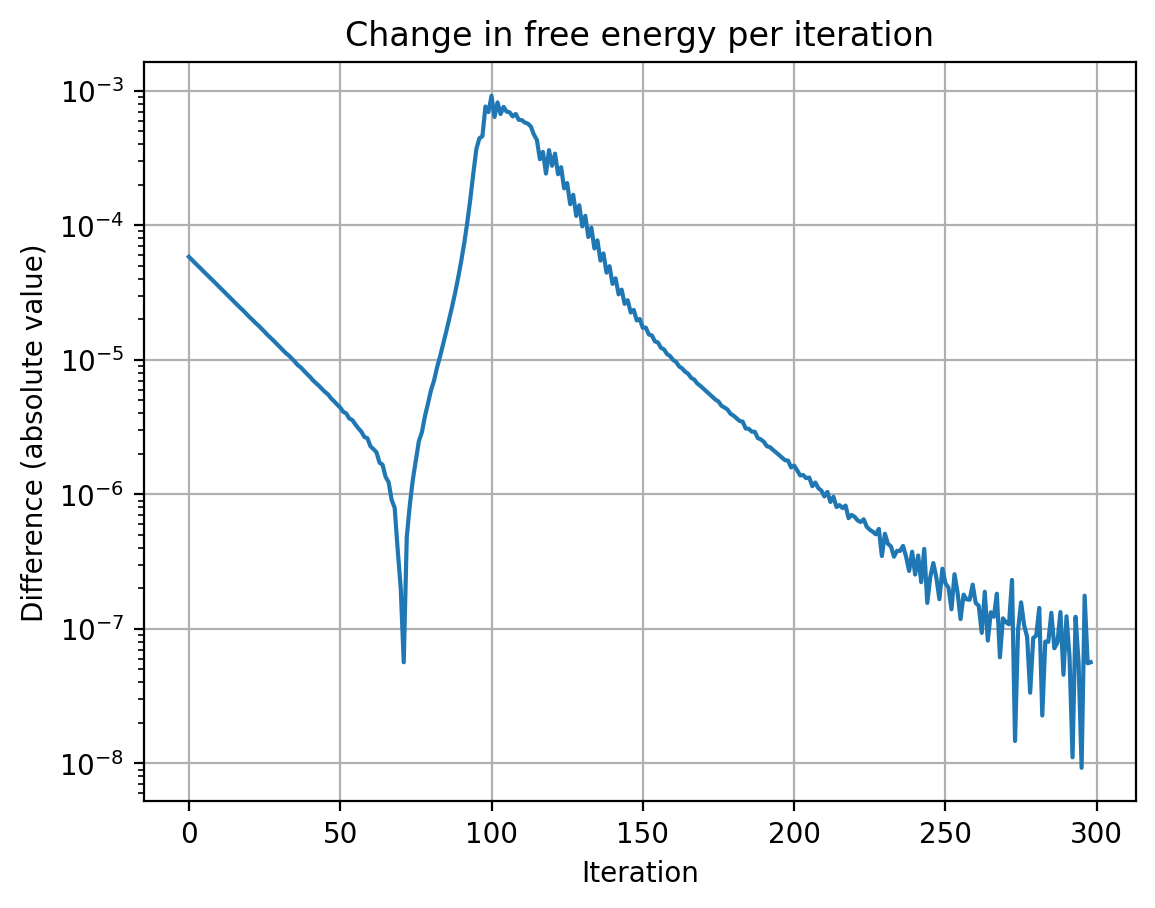

In [8]:
plt.figure(dpi=200)
diff_energy = free_energy_hist[1:, 0]-free_energy_hist[:-1, 0]
plt.plot(abs(diff_energy))
#plt.plot(diff_energy)
plt.yscale('log')
plt.title("Change in free energy per iteration")
plt.ylabel("Difference (absolute value)")
plt.xlabel("Iteration")
plt.grid()
#plt.ylim([-1e-6, 1e-6])

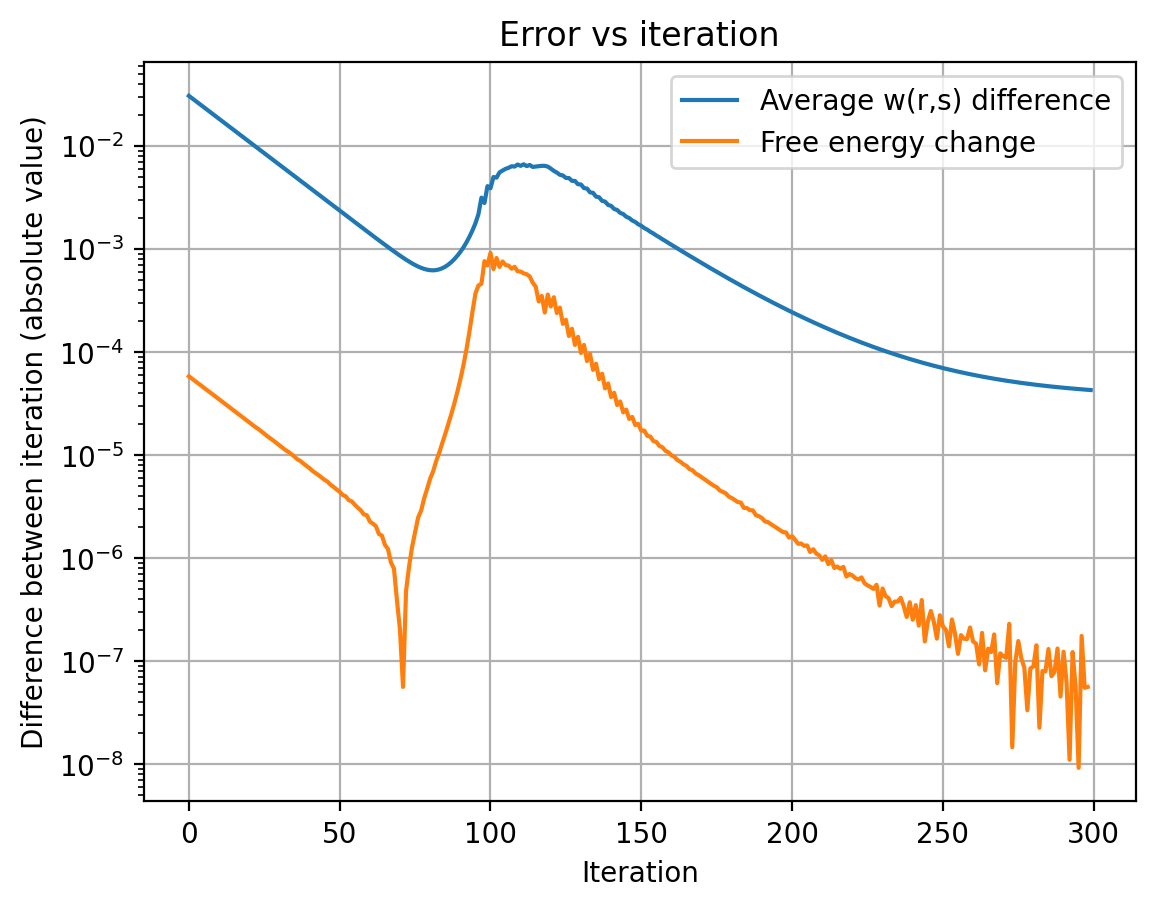

In [9]:
plt.figure(dpi=200)
plt.plot(diff, label="Average w(r,s) difference")
plt.plot(abs(diff_energy), label="Free energy change")
plt.yscale('log')
#plt.title("Average difference in w(r,s) per iteration")
plt.title("Error vs iteration")
plt.ylabel("Difference between iteration (absolute value)")
plt.xlabel("Iteration")
plt.grid()
plt.legend()

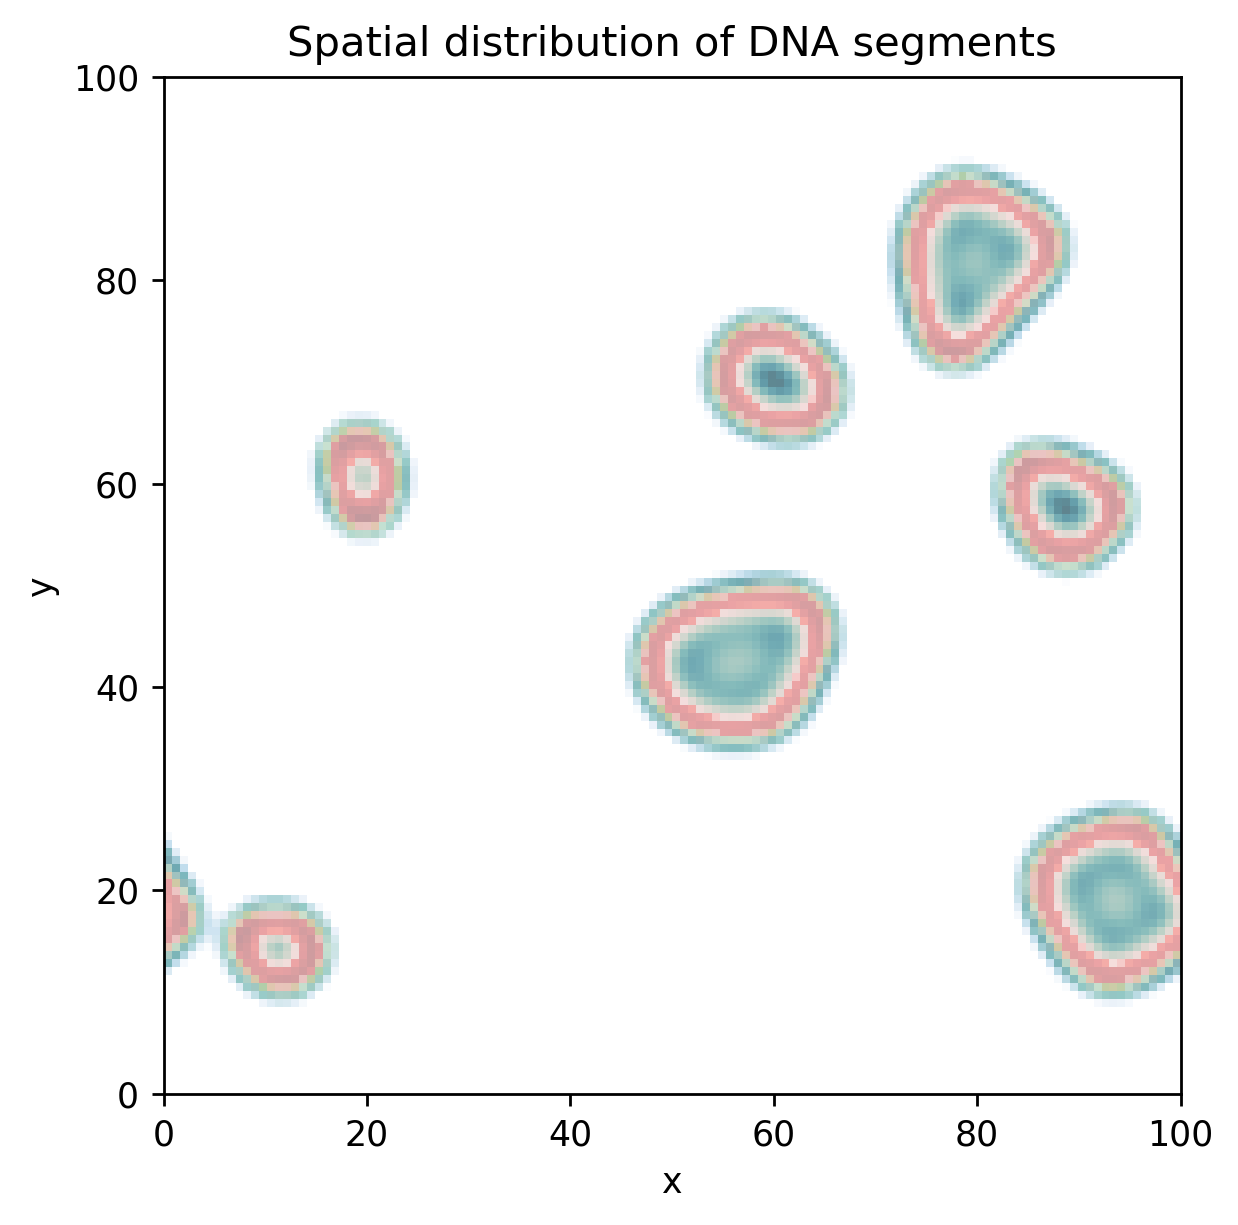

In [10]:
plot_phi_blocks_periodic(np.flip(to_numpy(phi_blocks), axis=0), extent=(0, polymer.Lx, 0, polymer.Ly), percentile=90, shift_x=0, shift_y=0)

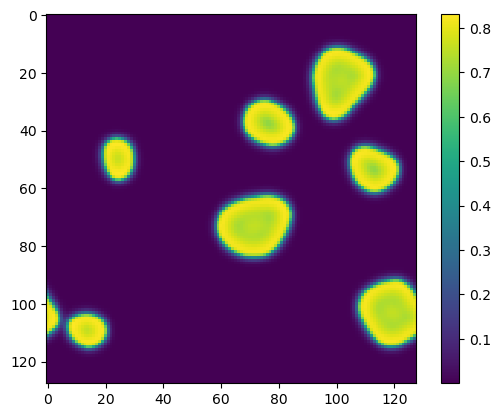

In [11]:
plt.imshow(np.flip(to_numpy(phi), axis = 0), cmap='viridis', interpolation='nearest', aspect=1)
plt.colorbar()

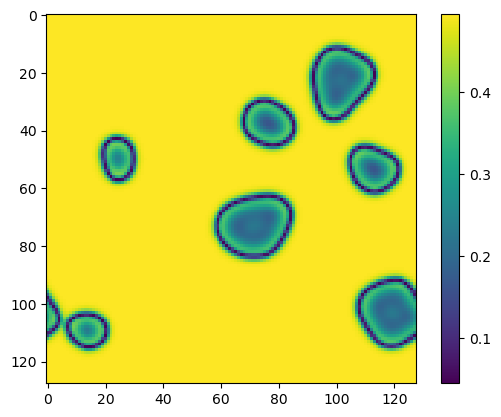

In [12]:
plt.imshow(np.flip(to_numpy(wsr[1]), axis = 0), cmap='viridis', interpolation='nearest', aspect=1)
plt.colorbar()

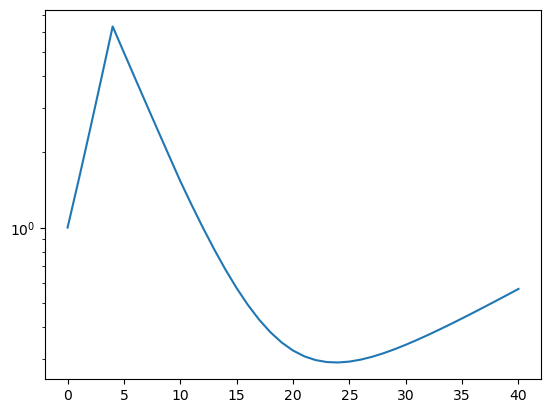

In [13]:
qsr_decay = np.mean(qsr, axis = (1,2))
plt.plot(to_numpy(qsr_decay))
plt.yscale('log')

parameter sweep for different polymer length and average density

In [19]:
from joblib import Parallel, delayed
from itertools import product

def single_run(N, phibar):

    PB = N//5

    polymer = Scft(
        N = N,
        Lx=L, Ly=L,
        phibar=phibar, # volume fraction of polymer
        l_p=np.sqrt(N),
        n_seg=1, # contour length of polymer normalized from 0-1
        nx=nx, ny=ny,
        ns=ns,
        iterations=500,
        error_tol=1e-12,
        chain_interaction=chain_interaction,
        self_avoiding=0,
        initial_qsr=initial_qsr / np.mean(initial_qsr),
        mixing_rate=0.03,
        chi_polymer_block = chi_matrix,
        chi_polymer_s = chi_polymer_s,
        PB = PB,
        close_boundary=True,
    )
    wsr, qsr_initial, qsr_d_initial, diff = initialization(polymer, seed = 5)
    wsr, phi, phi_blocks, qsr, qsr_d, diff = scft_loop(polymer, wsr, qsr_initial, qsr_d_initial, diff)

    return to_numpy(phi_blocks), to_numpy(qsr)

def parameter_sweep(num):
    N = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

    results = Parallel(n_jobs = 2, backend="threading")(
        delayed(single_run)(N)
        for N in N
    )

    phi_blocks_results, qsr_results = zip(*results)
    return phi_blocks_results, qsr_results

def parameter_sweep_2d(N_vals = 1, phibar_vals = 1, n_jobs=3, backend="loky", seed=5):
    """
    2D sweep over N and phibar.
    Returns:
        Ns: list[int]                 (length M)
        phibars: list[float]          (length K)
        phi_blocks_grid: (M, K) object array of phi_blocks
        qsr_grid:        (M, K) object array of qsr
    Indexing: [i, j] corresponds to N=Ns[i], phibar=phibars[j]
    """
    #Ns = np.asarray(N_vals, dtype=int)
    Ns = np.array([10, 15, 20, 30, 50, 75, 100])
    #phibars = np.asarray(phibar_vals, dtype=float)
    phibars = np.array([0.005, 0.01, 0.04,0.07, 0.1, 0.2, 0.4, 0.8])

    combos = list(product(Ns, phibars))  # order: outer over Ns, inner over phibars

    results = Parallel(n_jobs=n_jobs, backend=backend)(
        delayed(single_run)(N_, p_) for (N_, p_) in combos
    )
    phi_list, qsr_list = zip(*results)

    M, K = len(Ns), len(phibars)
    phi_blocks_grid = np.empty((M, K), dtype=object)
    qsr_grid        = np.empty((M, K), dtype=object)

    # Fill grids in the same order as product(Ns, phibars)
    idx = 0
    for i in range(M):
        for j in range(K):
            phi_blocks_grid[i, j] = phi_list[idx]
            qsr_grid[i, j] = qsr_list[idx]
            idx += 1

    return Ns.tolist(), phibars.tolist(), phi_blocks_grid, qsr_grid


In [20]:
Ns, phibars, phi_blocks_grid, qsr_grid = parameter_sweep_2d()

In [22]:
phi_blocks_grid = np.array(phi_blocks_grid)
print(phi_blocks_grid.shape)
print(phi_blocks_grid[3,3].shape)

(7, 8)
(3, 128, 128)


In [47]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_sweep_2d(phi_blocks_grid, Ns, phibars, Lx=L, Ly=L,
                  percentile=85, shift_x=0, shift_y=0, dpi=200):
    """
    phi_blocks_grid: object array with shape (len(Ns), len(phibars))
                     where [i, j] corresponds to N=Ns[i], phibar=phibars[j]
    """
    Ns = list(Ns)
    phibars = list(phibars)

    #if save_dir:
        #Path(save_dir).mkdir(parents=True, exist_ok=True)

    M, K = phi_blocks_grid.shape
    for i in range(M):
        for j in range(K):
            phi_blocks = phi_blocks_grid[i, j]

            # Clear any prior figures so we always work on the one just created
            plt.close('all')

            # Draw (this likely creates a new fig internally)
            plot_phi_blocks_periodic(
                np.flip(phi_blocks, axis=0),
                extent=(0, Lx, 0, Ly),
                percentile=percentile,
                shift_x=shift_x,
                shift_y=shift_y,
            )

            print(f"N = {int(Ns[i])},  φ̄ = {phibars[j]:g}")

            plt.show()



In [ ]:
plot_sweep_2d(phi_blocks_grid, Ns, phibars)